<a href="https://colab.research.google.com/github/kiran92345/Ai-health-assistant/blob/main/imageprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data from Google Drive

TensorFlow Version: 2.20.0
21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Upload an image...


Saving dead-space-remake-2022-games-3840x2160-6198.jpg to dead-space-remake-2022-games-3840x2160-6198.jpg


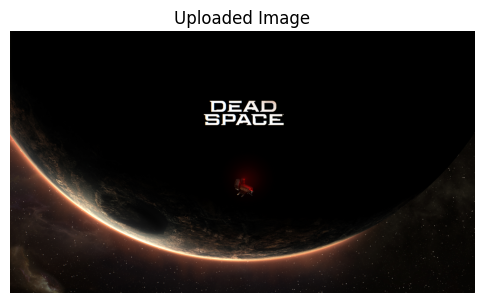

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Top Predictions
--------------------------------------------------
1. wok                       16.43%
2. candle                    11.54%
3. red_wine                  11.12%
4. gong                      5.52%
5. espresso                  2.60%

IMAGE QUALITY ANALYSIS
Brightness     : 14.87
Sharpness      : 183.55
Contrast       : 35.78
Noise Level    : 85.14
------------------------------------------------------------
Overall Score  : 23.35/100
Quality        : Poor ⭐⭐


In [ ]:
# ==========================================================
# IMAGE QUALITY ASSESSMENT PROJECT - GOOGLE COLAB (ONE BLOCK)
# ==========================================================

# Install required libraries
!pip -q install tensorflow opencv-python matplotlib pillow

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

print("TensorFlow Version:", tf.__version__)

# ----------------------------------------------------------
# Load Pretrained EfficientNetB0 Model
# ----------------------------------------------------------
model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=True
)

# ----------------------------------------------------------
# Upload Image
# ----------------------------------------------------------
print("\nUpload an image...")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# ----------------------------------------------------------
# Read Image
# ----------------------------------------------------------
img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# ----------------------------------------------------------
# Preprocess Image
# ----------------------------------------------------------
img_resized = img.resize((224,224))

img_array = np.array(img_resized)

x = np.expand_dims(img_array, axis=0)

x = tf.keras.applications.efficientnet.preprocess_input(x)

# ----------------------------------------------------------
# Predict
# ----------------------------------------------------------
pred = model.predict(x, verbose=0)

decoded = tf.keras.applications.efficientnet.decode_predictions(pred, top=5)[0]

print("\nTop Predictions")
print("-"*50)

for i,(id,label,prob) in enumerate(decoded):
    print(f"{i+1}. {label:25s} {prob*100:.2f}%")

# ----------------------------------------------------------
# Image Quality Metrics
# ----------------------------------------------------------

gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)

# Brightness
brightness = np.mean(gray)

# Sharpness
sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

# Contrast
contrast = np.std(gray)

# Noise Estimation
noise = np.std(gray - cv2.GaussianBlur(gray,(7,7),0))

# ----------------------------------------------------------
# Overall Quality Score
# ----------------------------------------------------------

quality = (
    min(brightness/255,1)*25 +
    min(sharpness/600,1)*35 +
    min(contrast/80,1)*25 +
    (1-min(noise/40,1))*15
)

quality = round(float(quality),2)

# ----------------------------------------------------------
# Quality Label
# ----------------------------------------------------------

if quality >= 85:
    label = "Excellent ⭐⭐⭐⭐⭐"
elif quality >= 70:
    label = "Good ⭐⭐⭐⭐"
elif quality >= 50:
    label = "Average ⭐⭐⭐"
else:
    label = "Poor ⭐⭐"

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------

print("\n" + "="*60)
print("IMAGE QUALITY ANALYSIS")
print("="*60)

print(f"Brightness     : {brightness:.2f}")
print(f"Sharpness      : {sharpness:.2f}")
print(f"Contrast       : {contrast:.2f}")
print(f"Noise Level    : {noise:.2f}")

print("-"*60)
print(f"Overall Score  : {quality}/100")
print(f"Quality        : {label}")
print("="*60)